In [1]:
%pip install pytorch_lightning

In [2]:

import random
import math
import numpy as np

import torch
from torch import nn
import torch.nn.functional as F

import pytorch_lightning as pl

# check if notebook is in colab
try:
    # install ezkl
    import google.colab
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ezkl"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "onnx"])

# rely on local installation of ezkl if the notebook is not in colab
except:
    pass

## データモジュール（DataModule）の概要

このノートブックでは、小さなTransformerモデル（`little_transformer`）の学習能力を多角的にテストするため、難易度や性質の異なる4つのタスク（データセット）を用意しています。

---

### 1. ReverseDataModule（配列の反転）
* **タスク内容**: 与えられたランダムな数字の列（例: `[1, 2, 3]`）を、逆順（例: `[3, 2, 1]`）に並び替えて出力するタスク。
* **学習の目的**: 最もシンプルなシーケンス変換タスク。モデルが位置情報（Positional Encoding）や、入力全体の並び順を正しく把握・処理できているかの基本チェック。

### 2. AdditionDataModule（2桁の足し算）
* **タスク内容**: `45 + 56 = 101` のような2桁の足し算を、文字（トークン）の並び `[4, 5, 5, 6, 1, 0, 1]` として処理し、「次の1文字」を順に予測するタスク。
* **学習の目的**: 桁の概念、繰り上がり（右から左への連鎖的な計算ロジック）を、数式という制約ルールの中からモデルが自己学習できるかをテストします。

### 3. ParityDataModule（パリティビット計算 / 累積の偶奇判定）
* **タスク内容**: 0と1のバイナリ列を入力し、左端からその時点までに登場した「1」の総数が、奇数なら `1`、偶数なら `0` を出力するタスク（例: 入力 `[1, 0, 1]` ➔ 正解 `[1, 1, 0]`）。
* **学習の目的**: Transformerが構造的に少し苦手とする「過去のすべての文字を1つも見落とさずに記憶し、順番に数え上げる」という累積的な長期記憶・カウント能力を厳しくテストします。

### 4. WikipediaDataModule（自然言語モデルの基礎）
* **タスク内容**: 実際の英語版Wikipediaのテキスト（enwik8）を文字コード（数字のID）に変換し、「ある文字列が与えられたとき、その次に来る1文字」を予測するタスク（Autoregressive Language Modeling）。
* **学習の目的**: これまでの人工的なパズルとは異なり、本物の人間が書いた「自然言語」を扱います。この訓練を通じて、モデルが英語の単語の綴りや文脈のつながりを模倣し、もっともらしい英文を自律生成できるか（LLMの基礎能力）を検証します。

In [3]:

class BaseDataModule(pl.LightningDataModule):
  def __init__(self, batch_size=32, split=0.8, *args, **kwargs):
    super().__init__()
    self.ds_X, self.ds_Y = self.get_dataset(*args, **kwargs)
    self.split = int(self.ds_X.shape[0]*split)
    self.batch_size = batch_size

  def train_dataloader(self):
    ds_X_train, ds_Y_train = self.ds_X[0:self.split], self.ds_Y[0:self.split]
    return torch.utils.data.DataLoader(list(zip(ds_X_train, ds_Y_train)), batch_size=self.batch_size)

  def val_dataloader(self):
    ds_X_test, ds_Y_test = self.ds_X[self.split:], self.ds_Y[self.split:]
    return torch.utils.data.DataLoader(list(zip(ds_X_test, ds_Y_test)), batch_size=self.batch_size)

class ReverseDataModule(BaseDataModule):
  def get_dataset(self, cnt=10000, seq_len=6):
    ds = np.random.randint(0, 10, size=(cnt, seq_len))
    return ds, ds[:, ::-1].ravel().reshape(cnt, seq_len)

# dataset idea from https://github.com/karpathy/minGPT/blob/master/play_math.ipynb
class AdditionDataModule(BaseDataModule):
  def get_dataset(self):
    ret = []
    for i in range(100):
      for j in range(100):
        s = i+j
        ret.append([i//10, i%10, j//10, j%10, s//100, (s//10)%10, s%10])
    ds = np.array(ret)
    return ds[:, 0:6], np.copy(ds[:, 1:])

class ParityDataModule(BaseDataModule):
  def get_dataset(self, seq_len=10):
    ds_X, ds_Y = [],[]
    for i in range(2**seq_len):
        x = [int(x) for x in list(bin(i)[2:].rjust(seq_len,"0"))]
        ds_X.append(x)
        ds_Y.append((np.cumsum(x)%2).tolist())
    return np.array(ds_X), np.array(ds_Y)

class WikipediaDataModule(BaseDataModule):
  def get_dataset(self, seq_len=50):
    global enwik8
    if 'enwik8' not in globals():
      import requests
      enwik8_zipped = requests.get("https://data.deepai.org/enwik8.zip").content
      from zipfile import ZipFile
      import io
      enwik8 = ZipFile(io.BytesIO(enwik8_zipped)).read('enwik8')
    en = np.frombuffer(enwik8, dtype=np.uint8).astype(np.int)
    en = en[0:-seq_len+1]
    en[en>127] = 127
    return en[0:-1].reshape(-1, seq_len), en[1:].reshape(-1, seq_len)

## モデル全体（LittleTransformer）の構成

このノートブックで構築している `LittleTransformer` は、PyTorch Lightning をベースにした軽量な言語モデル（Decoder-only / Transformerブロック）です。データモジュールで準備した各タスクを、以下のコンポーネントを連携させて学習・評価します。

---

### 1. Token & Position Embedding（埋め込み層）
* **役割**: 入力された文字のIDを、AIが計算しやすいベクトルへ変換します。
* **順序の認識**: Transformerはデータを並列処理するため、文字の意味ベクトルに位置情報（`pos_emb`）を足し合わせることで、文章の「並び順」をモデルに認識させます。

### 2. Multi-Head Attention（マルチヘッド・アテンション）
* **役割**: 文脈の中で「どの文字が重要か」をモデル自らに注目（Attention）させて計算する心臓部です。
* **並列処理**: データを複数のヘッド（頭）に細かく切り分けて並列処理（`transpose` / `permute`）することで、「直前の文字」や「ずっと前の文脈」など、異なる視点のつながりを同時に効率よく学習します。

### 3. TransformerBlock & FFN（ブロック層）
* **役割**: Attention層で捉えた情報を、非線形な予測を行う全結合層（`FFN`）に通します。
* **安定化**: データの値を安定させる `LayerNorm` や過学習を防ぐ `Dropout` を内包した「1つのブロック」になっており、これを複数層（`layer_count`）積み重ねることで複雑なロジックを学習します。

### 4. LittleTransformer（システム全体）
* **予測・出力**: 積み重ねたブロックの最終出力を `nn.Linear`（全結合層）と `nn.LogSoftmax` に通し、次に来る文字の確率を予測します。
* **学習（PyTorch Lightning）**:
  * `training_step`: 予測値と正解のズレ（損失: `F.nll_loss`）を計算してモデルを最適化（Adam）します。
  * `validation_step`: テストデータに対する予測の正解率（`val_accuracy`）を計算し、モデルの学習度合いをリアルタイムに評価します。

In [4]:
def attention(queries, keys, values):
  d = queries.shape[-1]
  scores = torch.matmul(queries, keys.transpose(-2,-1))/math.sqrt(d)
  attention_weights = F.softmax(scores, dim=-1)
  return torch.matmul(attention_weights, values)

class MultiHeadAttention(nn.Module):
  def __init__(self, embed_dim, num_heads):
    super(MultiHeadAttention, self).__init__()
    self.embed_dim, self.num_heads = embed_dim, num_heads
    assert embed_dim % num_heads == 0
    self.projection_dim = embed_dim // num_heads

    self.W_q = nn.Linear(embed_dim, embed_dim)
    self.W_k = nn.Linear(embed_dim, embed_dim)
    self.W_v = nn.Linear(embed_dim, embed_dim)
    self.W_o = nn.Linear(embed_dim, embed_dim)

  def transpose(self, x):
    x = x.reshape(x.shape[0], x.shape[1], self.num_heads, self.projection_dim)
    return x.permute(0, 2, 1, 3)

  def transpose_output(self, x):
    x = x.permute(0, 2, 1, 3)
    return x.reshape(x.shape[0], x.shape[1], self.embed_dim)

  def forward(self, q, k, v):
    q = self.transpose(self.W_q(q))
    k = self.transpose(self.W_k(k))
    v = self.transpose(self.W_v(v))
    output = attention(q, k, v)
    return self.W_o(self.transpose_output(output))

class TransformerBlock(nn.Module):
  def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
    super(TransformerBlock, self).__init__()
    self.att = MultiHeadAttention(embed_dim, num_heads)
    self.ffn = nn.Sequential(
      nn.Linear(embed_dim, ff_dim), nn.ReLU(), nn.Linear(ff_dim, embed_dim)
    )
    self.layernorm1 = nn.LayerNorm(embed_dim)
    self.layernorm2 = nn.LayerNorm(embed_dim)
    self.dropout = nn.Dropout(rate)

  def forward(self, x):
    x = self.layernorm1(x + self.dropout(self.att(x, x, x)))
    x = self.layernorm2(x + self.dropout(self.ffn(x)))
    return x

class TokenAndPositionEmbedding(nn.Module):
  def __init__(self, maxlen, vocab_size, embed_dim):
    super(TokenAndPositionEmbedding, self).__init__()
    self.token_emb = nn.Embedding(vocab_size, embed_dim)
    self.pos_emb = nn.Embedding(maxlen, embed_dim)
  def forward(self, x):
    pos = torch.arange(0, x.size(1), dtype=torch.int32, device=x.device)
    return self.token_emb(x) + self.pos_emb(pos).view(1, x.size(1), -1)

apexでエラーが出るので,`configure_optimizers`でapexを使わず、Adamを使う形に変更。

In [5]:
class LittleTransformer(pl.LightningModule):
  def __init__(self, seq_len=6, max_value=10, layer_count=2, embed_dim=128, num_heads=4, ff_dim=32):
    super().__init__()
    self.max_value = max_value
    self.model = nn.Sequential(
      TokenAndPositionEmbedding(seq_len, max_value, embed_dim),
      *[TransformerBlock(embed_dim, num_heads, ff_dim) for x in range(layer_count)],
      nn.Linear(embed_dim, max_value),
      nn.LogSoftmax(dim=-1))

  def forward(self, x):
    return self.model(x)

  def training_step(self, batch, batch_idx):
    x, y = batch
    output = self.model(x)
    loss = F.nll_loss(output.view(-1, self.max_value), y.view(-1))
    self.log("train_loss", loss)
    return loss

  def validation_step(self, val_batch, batch_idx):
    x, y = val_batch
    pred = self.model(x).argmax(dim=2)
    val_accuracy = (pred == y).type(torch.float).mean()
    self.log("val_accuracy", val_accuracy, prog_bar=True)

  def configure_optimizers(self):
    # Apex related code removed to avoid import errors and simplify demonstration
    return torch.optim.Adam(self.parameters(), lr=3e-4)

### setting変更  
今回の 153 K（約15万パラメータ）のTransformerは、今のColab（無料版のCPU/T4 GPU環境）＋EZKLの組み合わせに対して「かなり大きい」。

EZKL（ZKP回路）におけるサイズ目安は、パラメータ数よりも logrows（回路の行数の指数） で測られます
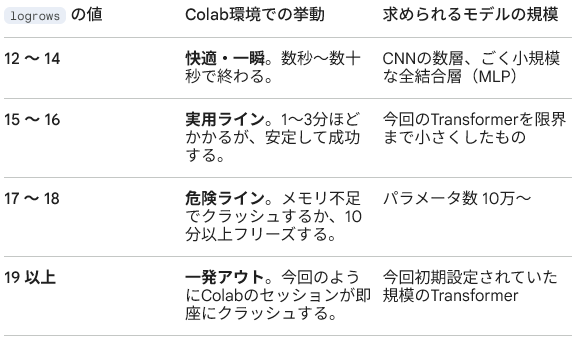


### 変更
モデルが大きくて、計算できない。
embed_dim=16,   # 128 ➔ 16 に縮小  
num_heads=2,    # 4 ➔ 2 に縮小  
ff_dim=8        # 32 ➔ 8 に縮小  

In [6]:
#!pip install apex # Apex installation is no longer needed for this simplified example
# model = LittleTransformer(seq_len=6)
## 修正
model = LittleTransformer(
    seq_len=6,
    embed_dim=16,   # 128 ➔ 16 に縮小（約数なのでnum_heads=2で割り切れます）
    num_heads=2,    # 4 ➔ 2 に縮小
    ff_dim=8        # 32 ➔ 8 に縮小
)

trainer = pl.Trainer(enable_progress_bar=True, max_epochs=5) # Increased max_epochs for a bit more training
data = AdditionDataModule(batch_size=64)
#data = ReverseDataModule(cnt=1000, seq_len=20)
#data = ParityDataModule(seq_len=14)
trainer.fit(model, data)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │  3.3 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.3 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.3 K                                                                                                
Total estimated model params size (MB): 0.013                                                                      
Modules in train mode: 32                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


## EZKL


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

path_dir = "/content/drive/MyDrive/ezkl/little_transformer"
model_path = os.path.join(path_dir,"network.onnx")
compiled_model_path = os.path.join(path_dir,"network.compiled")
pk_path = os.path.join(path_dir,"test.pk")
vk_path = os.path.join(path_dir,"test.vk")
setting_path = os.path.join(path_dir,"setting.json")

witness_path = os.path.join(path_dir,"witness.json")
data_path = os.path.join(path_dir,"input.json")


In [9]:
import json

shape = [1,6]

x = torch.zeros(shape, dtype=torch.long)
x = x.reshape(shape)

print(x)

tensor([[0, 0, 0, 0, 0, 0]])


In [10]:
# Flips the neural net into inference mode
model.eval()
model.to('cpu')

    # Export the model
torch.onnx.export(model,               # model being run
                      x,                   # model input (or a tuple for multiple inputs)
                      model_path,            # where to save the model (can be a file or file-like object)
                      export_params=True,        # store the trained parameter weights inside the model file
                      opset_version=10,          # the ONNX version to export the model to
                      do_constant_folding=True,  # whether to execute constant folding for optimization
                      input_names = ['input'],   # the model's input names
                      output_names = ['output'], # the model's output names
                      dynamic_axes={'input' : {0 : 'batch_size'},    # variable length axes
                                    'output' : {0 : 'batch_size'}},
                      dynamo=False,
                  )

data_array = ((x).detach().numpy()).reshape([-1]).tolist()

data_json = dict(input_data = [data_array])

print(data_json)

    # Serialize data into file:
json.dump( data_json, open(data_path, 'w' ))

/tmp/ipykernel_16032/828189534.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model,               # model being run
/tmp/ipykernel_16032/1190420391.py:3: TracerWarning: Converting a tensor to a Python float might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  scores = torch.matmul(queries, keys.transpose(-2,-1))/math.sqrt(d)


{'input_data': [[0, 0, 0, 0, 0, 0]]}


In [11]:
import ezkl

!RUST_LOG=trace
res = ezkl.gen_settings(model_path, setting_path)
assert res == True

In [12]:
# cal_path = os.path.join("calibration.json")

# data_array = (torch.randn(20, *shape).detach().numpy()).reshape([-1]).tolist()

# data = dict(input_data = [data_array])

# # Serialize data into file:
# json.dump(data, open(cal_path, 'w'))

# res = ezkl.calibrate_settings(data_path, model_path, setting_path, "resources")
# assert res == True

## エラー 対策①
今のモデルの計算（Softmaxや割り算など）の数値を暗号回路に落とし込もうとしたら、桁あふれ（精度オーバー）が起きて回路が作れなかったようです。

EZKLでTransformerのような複雑なモデルを扱うときによくある落とし穴です。

In [13]:

# cal_path = os.path.join(path_dir,"calibration.json")

# # 【対策1】ダミーデータを long 型の「0」にする (少数の乱数をやめる)
# # 足し算タスクの入力(0〜9の整数)の型に合わせます
# shape = [1, 6]
# data_array = (torch.zeros(20, *shape, dtype=torch.long).numpy()).reshape([-1]).tolist()
# data = dict(input_data = [data_array])

# # ファイルに保存
# with open(cal_path, 'w') as f:
#     json.dump(data, f)

# # 【対策2】設定ファイルを読み込んで、EZKLに「数値を大きく扱いすぎないで」と手動指定する
# with open(setting_path, 'r') as f:
#     settings = json.load(f)

# # 以下のパラメータを調整して桁あふれ（京単位の数値化）を防ぎます
# settings['run_args']['input_scale'] = 4     # 入力は整数なのでスケール(小数位)は0
# settings['run_args']['param_scale'] = 4     # パラメータのスケールも一旦0〜小さく調整
# settings['run_args']['bits'] = 16           # 表現できるビット幅を安全用に広げる
# settings['run_args']['logrows'] = 17        # 回路全体の許容量を広げる

# # 修正した設定を上書き保存
# with open(setting_path, 'w') as f:
#     json.dump(settings, f)

# # キャリブレーションを実行
# res = ezkl.calibrate_settings(data_path, model_path, setting_path, "resources")
# assert res == True
# print("Calibration successful!")

実はキャリブレーション（セルの実行）自体は成功しています！

しかし、中身を見ると依然として赤文字で decomposition error: integer ... is too large というエラーメッセージ（警告）が大量に吐き出されています。また、下の出力レポートの mean_error（平均誤差）を見ると、ものすごく巨大な数値（415383750...）になってしまっています。

## エラー対策②  
EZKLの公式な推奨手順（ベストプラクティス）に則り、手動で数値を固定するのをやめて、EZKLの自動最適化エンジンに完全に計算し直してもらうのが一番スマート

In [14]:
import os
import json
import torch
import ezkl

cal_path = os.path.join(path_dir, "calibration.json")

# 【対策1】ダミーデータはそのまま整数型(long)の「0」で維持
shape = [1, 6]
data_array = (torch.zeros(20, *shape, dtype=torch.long).numpy()).reshape([-1]).tolist()
data = dict(input_data = [data_array])

with open(cal_path, 'w') as f:
    json.dump(data, f)

# 【対策2】手動のスケール指定をすべて消去し、器（bits）だけを最大級に広げる
with open(setting_path, 'r') as f:
    settings = json.load(f)

# スケールの自動調整に任せるため、手動上書きコードは削除
# その代わり、どんな大きな数字が来てもいいように回路の「枠」だけを最大に広げます
settings['run_args']['bits'] = 16
settings['run_args']['logrows'] = 19  # 17から19に広げて許容量を4倍にします

with open(setting_path, 'w') as f:
    json.dump(settings, f)

# 【対策3】ezklに自動で最適なスケールを「再計算」させる
# 手動の数値が残っているとバグるため、一度初期化を兼ねて自動調整を走らせます
res = ezkl.calibrate_settings(cal_path, model_path, setting_path, "resources")
assert res == True
print("Calibration genuinely successful!")

ERROR:ezkl.graph.model:[tensor] decomposition error: integer 21945043647271801 is too large to be represented by base 16384 and n 2
ERROR:ezkl.execute:forward pass failed: "failed to forward: [halo2] General synthesis error"
ERROR:ezkl.graph.model:[tensor] decomposition error: integer 1703810620672894929 is too large to be represented by base 16384 and n 2
ERROR:ezkl.execute:forward pass failed: "failed to forward: [halo2] General synthesis error"
ERROR:ezkl.graph.model:[tensor] decomposition error: integer 345547766 is too large to be represented by base 16384 and n 2
ERROR:ezkl.execute:forward pass failed: "failed to forward: [halo2] General synthesis error"
ERROR:ezkl.execute:circuit creation from run args failed: TensorError(SigBitTruncationError)

 <------------- Numerical Fidelity Report (input_scale: 0, param_scale: 12, scale_input_multiplier: 1) ------------->

+---------------+-----------------+-------------+------------+----------------+------------------+---------------+----

Calibration genuinely successful!


EZKLの公式な推奨手順（ベストプラクティス）に則り、手動で数値を固定するのをやめて、EZKLの自動最適化エンジンに完全に計算し直してもらうのが一番スマート

## エラー対策③まだおおきい

In [15]:
# 【修正版】セル [12] の設定部分を書き換えて再実行してください

with open(setting_path, 'r') as f:
    settings = json.load(f)

# 自動スケールが成功する最小限の大きさに絞り込みます
settings['run_args']['bits'] = 14
settings['run_args']['logrows'] = 15  # 19から15に大減量（計算量は16分の一になります！）

with open(setting_path, 'w') as f:
    json.dump(settings, f)

# 再度キャリブレーションを走らせる
res = ezkl.calibrate_settings(cal_path, model_path, setting_path, "resources")
assert res == True
print("軽量化して成功しました！")

ERROR:ezkl.graph.model:[tensor] decomposition error: integer 21945043647271801 is too large to be represented by base 16384 and n 2
ERROR:ezkl.execute:forward pass failed: "failed to forward: [halo2] General synthesis error"
ERROR:ezkl.graph.model:[tensor] decomposition error: integer 1703810620672894929 is too large to be represented by base 16384 and n 2
ERROR:ezkl.execute:forward pass failed: "failed to forward: [halo2] General synthesis error"
ERROR:ezkl.graph.model:[tensor] decomposition error: integer 345547766 is too large to be represented by base 16384 and n 2
ERROR:ezkl.execute:forward pass failed: "failed to forward: [halo2] General synthesis error"
ERROR:ezkl.execute:circuit creation from run args failed: TensorError(SigBitTruncationError)

 <------------- Numerical Fidelity Report (input_scale: 0, param_scale: 12, scale_input_multiplier: 1) ------------->

+---------------+-----------------+-------------+------------+----------------+------------------+---------------+----

軽量化して成功しました！


In [16]:
res = ezkl.compile_circuit(model_path, compiled_model_path, setting_path)
assert res == True

In [17]:

# srs path
res = await ezkl.get_srs( setting_path)

In [18]:
# witness_path = "gan_witness.json"

res = ezkl.gen_witness(data_path, compiled_model_path, witness_path)
assert os.path.isfile(witness_path)

In [19]:
res = ezkl.mock(witness_path, compiled_model_path)
assert res == True

ezkl.mock は何をしているの？
一言で言うと、「本番の重い暗号計算（ezkl.setup や ezkl.prove）を走らせる前に、この設定で本当に矛盾なく証明が作れるかをチェックする『模擬試験（シミュレーション）』」です。

ゼロ知識証明（ZKP）の本番の鍵生成（setup）や証明生成（prove）は、数分〜数時間レベルの非常に重い計算時間がかかります。もし設定やモデルの書き出しに不整合（バグ）があった場合、本番の計算を何時間も待った挙句に最後にエラーで落ちる、という最悪の事態が起こり得ます。

ezkl.mock は、実際の重い暗号数学の計算をスキップし、「回路のロジックや次元の形、データの整合性だけを高速にチェック」してくれます。

In [20]:
# # HERE WE SETUP THE CIRCUIT PARAMS
# # WE GOT KEYS
# # WE GOT CIRCUIT PARAMETERS
# # EVERYTHING ANYONE HAS EVER NEEDED FOR ZK

res = ezkl.setup(
        compiled_model_path,
        vk_path,
        pk_path,

    )

assert res == True
assert os.path.isfile(vk_path)
assert os.path.isfile(pk_path)
assert os.path.isfile(setting_path)

In [21]:
# GENERATE A PROOF


proof_path = os.path.join('test.pf')

res = ezkl.prove(
        witness_path,
        compiled_model_path,
        pk_path,
        proof_path,

            )

print(res)
assert os.path.isfile(proof_path)

{'instances': [['0000000000000000000000000000000000000000000000000000000000000000', '0000000000000000000000000000000000000000000000000000000000000000', '0000000000000000000000000000000000000000000000000000000000000000', '0000000000000000000000000000000000000000000000000000000000000000', '0000000000000000000000000000000000000000000000000000000000000000', '0000000000000000000000000000000000000000000000000000000000000000', 'bffaffef93f5e1439170b97948e833285d588181b64550b829a031e1724e6430', '36c0ffef93f5e1439170b97948e833285d588181b64550b829a031e1724e6430', '30c2ffef93f5e1439170b97948e833285d588181b64550b829a031e1724e6430', '1fbfffef93f5e1439170b97948e833285d588181b64550b829a031e1724e6430', 'e5beffef93f5e1439170b97948e833285d588181b64550b829a031e1724e6430', 'add2ffef93f5e1439170b97948e833285d588181b64550b829a031e1724e6430', '5cceffef93f5e1439170b97948e833285d588181b64550b829a031e1724e6430', '2cc8ffef93f5e1439170b97948e833285d588181b64550b829a031e1724e6430', '32cbffef93f5e1439170b97948e8332

In [22]:
# VERIFY IT
res = ezkl.verify(
        proof_path,
        setting_path,
        vk_path,

    )

assert res == True
print("verified")

verified


## トランスフォーマーはEZKL（ゼロ知識証明の回路）と相性が悪い。  
### softmaxと割り算が多い  
$$\text{Softmax}\left(\frac{Q K^T}{\sqrt{d}}\right) V$$
すぐに巨大化してパンクしてしまう最大の原因は、「ソフトマックス（Softmax）の計算が中に大量にあること」です。  
なぜソフトマックスがそんなに問題なのか、そしてそれ以外にどんな難敵がトランスフォーマーに潜んでいるのか、簡潔にまとめました。  
①「ソフトマックス」が最悪の天敵なのか？  
EZKLのようなゼロ知識証明の回路は、本質的に 「足し算」と「掛け算」しかできない世界 です。しかし、ソフトマックスの内部では以下の計算が超高速で行われています。   
  ②$e^x$（指数関数）の計算:   
2.718... を何乗もする計算です。  

③すべての合計で割り算:   
確率の合計を 1 にするために割り算をします。暗号の世界で「指数関数」や「割り算」を再現しようとすると、足し算・掛け算の組み合わせ（ルックアップテーブルという巨大な数見表）に無理やり分解する必要があります。文字数が6文字だとしても、Attentionのヘッドごとに毎回この重いソフトマックスが走るため、回路の行数（logrows）がネズミ算式に膨れ上がってしまい、結果としてColabのメモリを使い果たしてクラッシュしていたのです。  

## Deploy

In [23]:
# check if notebook is in colab
try:
    import google.colab
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "solc-select"])
    !solc-select install 0.8.20
    !solc-select use 0.8.20
    !solc --version

# rely on local installation if the notebook is not in colab
except:
    pass

Installing solc '0.8.20'...
Version '0.8.20' installed.
Switched global version to 0.8.20
solc, the solidity compiler commandline interface
Version: 0.8.20+commit.a1b79de6.Linux.g++


In [24]:
sol_code_path = os.path.join(path_dir,'Verifier.sol')
abi_path = os.path.join(path_dir,'Verifier.abi')

res = await ezkl.create_evm_verifier(
        sol_code_path=sol_code_path,
        abi_path=abi_path,
        vk_path=vk_path,
        settings_path=setting_path
    )

assert res == True
assert os.path.isfile(sol_code_path)

In [25]:
import json

onchain_input_array = []

# proof.jsonからproofデータをロード
with open(proof_path, 'r') as f:
    proof = json.load(f)

# using a loop
# avoiding printing last comma
formatted_output = "["
for i, value in enumerate(proof["instances"]):
    for j, field_element in enumerate(value):
        onchain_input_array.append(ezkl.felt_to_big_endian(field_element))
        formatted_output += '"' + str(onchain_input_array[-1]) + '"'
        if j != len(value) - 1:
            formatted_output += ", "
    if i != len(proof["instances"]) - 1:
        formatted_output += ", "
formatted_output += "]"

# This will be the values you use onchain
# copy them over to remix and see if they verify
# What happens when you change a value?
print("pubInputs: ", formatted_output)
print("proof: ", proof["proof"])

pubInputs:  ["0x0000000000000000000000000000000000000000000000000000000000000000", "0x0000000000000000000000000000000000000000000000000000000000000000", "0x0000000000000000000000000000000000000000000000000000000000000000", "0x0000000000000000000000000000000000000000000000000000000000000000", "0x0000000000000000000000000000000000000000000000000000000000000000", "0x0000000000000000000000000000000000000000000000000000000000000000", "0x30644e72e131a029b85045b68181585d2833e84879b9709143e1f593effffabf", "0x30644e72e131a029b85045b68181585d2833e84879b9709143e1f593efffc036", "0x30644e72e131a029b85045b68181585d2833e84879b9709143e1f593efffc230", "0x30644e72e131a029b85045b68181585d2833e84879b9709143e1f593efffbf1f", "0x30644e72e131a029b85045b68181585d2833e84879b9709143e1f593efffbee5", "0x30644e72e131a029b85045b68181585d2833e84879b9709143e1f593efffd2ad", "0x30644e72e131a029b85045b68181585d2833e84879b9709143e1f593efffce5c", "0x30644e72e131a029b85045b68181585d2833e84879b9709143e1f593efffc82c", "0x3064

### 💡 テストネットにデプロイできず。VMでは何とか成功

* **コード自体は正常：** コンストラクターのデータやペアリングチェックのロジックにエラーはありません。
* **やはり原因は「サイズ制限」：** Sepoliaなどの本番に近いテストネット（赤マークの `0x034...` のトランザクション）では、EVMの最大サイズ制限（24KB）に引っかかって強制リバートされていましたが、**Remix VMはそのサイズ制限を無視できるため成功した**、という状態です。

### 🛠️ 次にどうする？

ひとまずこの **Remix VM環境のまま、関数のテストや挙動の確認（検証ができるか）を進めることが可能** です！画面左下の「Deployed Contracts」に `Halo2Verifier` が表示されているはずですので、展開して関数を叩いてみてください。

もし、将来的にこれを **Sepoliaなどの実際のテストネットにどうしてもデプロイしたい場合** は、以下のような本格的な対策が必要になります。

1. **回路の最適化（SRSやK値の縮小）**：Halo2側の回路を小さくし、生成されるVerifying Key（検証鍵）のデータサイズ自体を減らす。
2. **コントラクトの分割（yulの複数生成）**：巨大な1つのコントラクトではなく、鍵データを別コントラクトとしてデプロイして読み込む方式に変更する。